In [56]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from dask.distributed import Client, LocalCluster

In [4]:
cluster=LocalCluster()
client=Client(cluster)

In [5]:
#load some data, filter, and 
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/shendure/shendure_counts_grouped.txt")
filtered,dropped_groups=scm.filter_low_umi_count(dat)
dropped_groups

{'cre_id': ['Col1a1_chr11_15306', 'Col1a2_chr6_65', 'minP_w_20bp_buffer'],
 'cell_type': []}

In [89]:
var_mean_relationship=filtered[['cre_id','cell_type','umis_mpra_bc']].groupby(['cre_id','cell_type']).agg(['mean','var']).sort_values(by=("umis_mpra_bc","mean"))
var_mean_relationship

umis_mpra_bc               
                                                  mean            var
cre_id            cell_type                                          
Klf4_chr4_3952    Haematoendothelial          0.000000       0.000000
Tgfbi_chr13_5711  EpiblastPrimitiveStreak     0.000000       0.000000
Epas1_chr17_10064 Cardiomyocytes              0.000000       0.000000
Epas1_chr17_10063 NeuroectodermRostral        0.000000       0.000000
Epas1_chr17_10057 Haematoendothelial          0.000000       0.000000
...                                                ...            ...
eef1aP            NeuroectodermBrain        181.604575   66571.625349
                  ExEndodermVisceral        203.566492   92673.591748
                  Haematoendothelial        245.192488  117678.809920
                  Pluripotent               358.843377  119757.878409
                  EpiblastPrimitiveStreak   432.394322  226198.243756

[2090 rows x 2 columns]

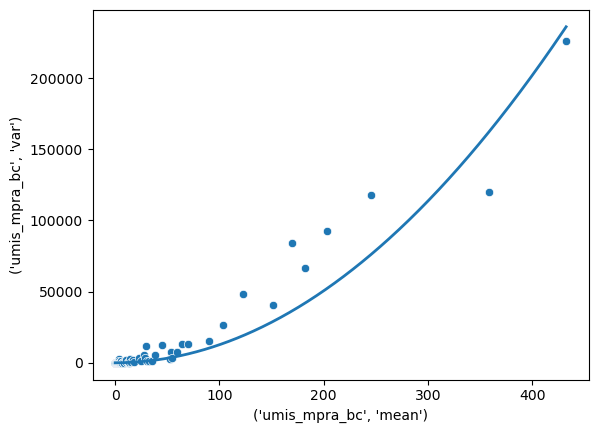

In [95]:
sns.scatterplot(var_mean_relationship,x=('umis_mpra_bc','mean'),y=('umis_mpra_bc','var'))

x=var_mean_relationship[('umis_mpra_bc','mean')]
y=var_mean_relationship[('umis_mpra_bc','var')]

y_adjusted = y - x
X = x**2
a = np.sum(X * y_adjusted) / np.sum(X * X)


x_line = np.linspace(x.min(), x.max(), 500)
y_line = a * x_line**2 + x_line
# overlay the curve
plt.plot(x_line, y_line, linewidth=2)

plt.show()

In [96]:
a

1.260425035479696

In [6]:
#run first time & cache on disc. If it's not the first time, load from disc instead. 
first_run=False

primordial=None

if first_run:
    primordial=scm.ortho()
    primordial.criss_cross(client=client,dat=filtered)
    primordial.extract_params(client)
    primordial.save('/gpfs/gibbs/pi/reilly/tabula_data/shendure','ortho')
else:
    primordial=scm.ortho.load(client,'/gpfs/gibbs/pi/reilly/tabula_data/shendure','ortho')

In [7]:
#create a simulation batch object
batch=scm.simulation_batch(primordial)
batch.describe_primordial(client,filtered)

In [8]:
description=batch.description_primordial_by_cre.compute()
description.to_csv("shendure_prim.tsv",sep="\t")

In [9]:
description.sort_values(by="nb")
#max(description["nb"])

,C(cell_type)[Cardiomyocytes],C(cell_type)[EpiblastPrimitiveStreak],C(cell_type)[ExEndodermParietal],C(cell_type)[ExEndodermVisceral],C(cell_type)[Haematoendothelial],C(cell_type)[Mesoderm],C(cell_type)[NeuroectodermBrain],C(cell_type)[NeuroectodermRostral],C(cell_type)[Pluripotent],C(cell_type)[SurfaceEctoderm],...,C(rep_id)[B1],C(rep_id)[B2],cre_id,cells,nb,zi,theta,r,sigmasquare,p
4291,0,0,0,1,0,0,0,0,0,0,...,0,0,Sox17_chr1_83,22,7.090039e-262,0.755683,-0.917572,0.399488,7.090039e-262,1.000000e+00
4284,0,0,0,1,0,0,0,0,0,0,...,0,1,Sox17_chr1_83,33,7.090039e-262,0.805551,-0.917572,0.399488,7.090039e-262,1.000000e+00
4281,0,0,0,1,0,0,0,0,0,0,...,0,0,Sox17_chr1_83,36,7.090039e-262,0.506100,-0.917572,0.399488,7.090039e-262,1.000000e+00
4278,0,0,0,1,0,0,0,0,0,0,...,1,0,Sox17_chr1_83,49,7.090039e-262,0.805446,-0.917572,0.399488,7.090039e-262,1.000000e+00
4269,0,0,0,1,0,0,0,0,0,0,...,0,0,Sox17_chr1_83,61,7.090039e-262,0.929513,-0.917572,0.399488,7.090039e-262,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3388,0,1,0,0,0,0,0,0,0,0,...,0,1,eef1aP,163,1.451269e+138,0.000498,-4.877599,0.007615,2.765732e+278,5.247323e-141
3386,0,1,0,0,0,0,0,0,0,0,...,0,0,eef1aP,213,1.451269e+138,0.000618,-4.877599,0.007615,2.765732e+278,5.247323e-141
3385,0,1,0,0,0,0,0,0,0,0,...,0,0,eef1aP,220,1.451269e+138,0.000608,-4.877599,0.007615,2.765732e+278,5.247323e-141
3375,0,1,0,0,0,0,0,0,0,0,...,0,0,eef1aP,292,1.451269e+138,0.000251,-4.877599,0.007615,2.765732e+278,5.247323e-141


In [66]:
description.sort_values(by="nb")['nb'].to_csv("lsjkdfhlasjkdhflasjkd.tsv",sep="\t")

In [10]:
description[description["cre_id"]=="eef1aP"][description["C(rep_id)[B2]"]==1][description["C(cell_type)[Pluripotent]"]==1]

,C(cell_type)[Cardiomyocytes],C(cell_type)[EpiblastPrimitiveStreak],C(cell_type)[ExEndodermParietal],C(cell_type)[ExEndodermVisceral],C(cell_type)[Haematoendothelial],C(cell_type)[Mesoderm],C(cell_type)[NeuroectodermBrain],C(cell_type)[NeuroectodermRostral],C(cell_type)[Pluripotent],C(cell_type)[SurfaceEctoderm],...,C(rep_id)[B1],C(rep_id)[B2],cre_id,cells,nb,zi,theta,r,sigmasquare,p
3358,0,0,0,0,0,0,0,0,1,0,...,0,1,eef1aP,508,1.662389e+106,0.000498,-4.877599,0.007615,3.628938e+214,4.580923e-109


In [97]:
set_of_interest=filtered[filtered["cre_id"]=="eef1aP"][filtered["rep_id"]=="B2"][filtered["cell_type"]=="Pluripotent"]

In [102]:
set_of_interest

,cell_bc,rep_id,cre_class,cre_id,cell_type,transfection_bc,mpra_bc,reads_transfection_bc,umis_transfection_bc,reads_mpra_bc,umis_mpra_bc,gex_umi,normalized_umis_mpra_bc
654465,B2_AAAGGATAGTATGGAT-1,B2,promoters,eef1aP,Pluripotent,ATCAGCTTGGGTGATT,CCTGCCCTAACGTTA,397,329,8549,468,4088,342.902936
654597,B2_AAAGGATTCGCCAGTG-1,B2,promoters,eef1aP,Pluripotent,"AATAACCTATCTCAAC, AACCGATGGCCTGTTC","CCGGGGACTACAACC, CCCCTAGTTACCCCC",87,68,466,24,3254,44.183481
654876,B2_AAAGTCCAGTTCCAGT-1,B2,promoters,eef1aP,Pluripotent,GCACATCAATGCACAA,ACACGCACGACCTAA,259,230,2671,130,3920,99.332993
655258,B2_AACAAAGCAACGCATT-1,B2,promoters,eef1aP,Pluripotent,GCAGAAACCACTAAAA,CCCCGCAACGCACGA,98,87,417,20,2226,26.911696
655320,B2_AACAACCAGAGATCGC-1,B2,promoters,eef1aP,Pluripotent,CTGACATAACCGAAAA,GTTCTAGCGATCTCA,196,172,9743,436,3130,417.232749
...,...,...,...,...,...,...,...,...,...,...,...,...,...
777271,B2_TTTCCTCTCAAGAAAC-1,B2,promoters,eef1aP,Pluripotent,"CGTAATAGCCTCCACC, ATACCTACCCAAACGA","TGCTCCGTAAGCCGT, ACCACGCGTCTCATG",633,551,5045,306,7298,251.179274
777285,B2_TTTCCTCTCATCACAG-1,B2,promoters,eef1aP,Pluripotent,"AAACACATGGACACGT, ATTGCGTCAGCCGCTT","GATTGACATCACCTA, TTCGTGCGCTACACC",67,59,4984,317,2678,709.112144
777606,B2_TTTGATCAGAGTGGCT-1,B2,promoters,eef1aP,Pluripotent,ACACGCTAAAAACACC,TACTTAACACACGCA,40,37,1716,80,1381,173.513211
777617,B2_TTTGATCAGTAATTGG-1,B2,promoters,eef1aP,Pluripotent,ACCTCCGCGCCCCTGC,TTTCGATCCACGACG,17,17,0,0,2243,0.000000


In [100]:
set_of_interest["umis_mpra_bc"].agg('mean')

375.93110236220474

In [101]:
len(set_of_interest)

508

In [13]:
sum(set_of_interest["umis_mpra_bc"]==0)/len(set_of_interest)

0.04330708661417323

This is a problem : the actual mean is like `376`, but our estimation is `1.662389e+106`. Where is the error coming from? Let's back up a few steps. Do the betas look OK? This is in a "by_cre" model. Let's find the `eef1aP` model & inspect it.

In [14]:
eef=primordial.by_cre.result().model["eef1aP"]

In [15]:
eef

{'llf_total': -118149.75108833611,
 'llfs': array([-118149.75108834]),
 'aic_total': 236333.50217667222,
 'aics': array([236333.50217667]),
 'df_model_total': 17,
 'df': 17,
 'weights': {'x_mu': array([[ 55.405197 ],
         [318.12918  ],
         [  3.8032186],
         [ 89.29445  ],
         [130.92244  ],
         [  8.234615 ],
         [ 67.3339   ],
         [  3.987131 ],
         [244.58228  ],
         [  4.6373167]], dtype=float32),
  'x_pi': array([[-7.4051566],
         [-8.288645 ],
         [-7.388765 ],
         [-7.3142934],
         [-8.630404 ],
         [-7.6042595]], dtype=float32),
  'theta': array([[-4.8775992]], dtype=float32)},
 'cpu_time': 3.343755006790161,
 'num_sample': 14191,
 'epochs': 986}

On initial inspection, the weights look fine.

In [16]:
primordial.by_cre.result().uniq_predictor["eef1aP"][0]

,C(cell_type)[Cardiomyocytes],C(cell_type)[EpiblastPrimitiveStreak],C(cell_type)[ExEndodermParietal],C(cell_type)[ExEndodermVisceral],C(cell_type)[Haematoendothelial],C(cell_type)[Mesoderm],C(cell_type)[NeuroectodermBrain],C(cell_type)[NeuroectodermRostral],C(cell_type)[Pluripotent],C(cell_type)[SurfaceEctoderm]
58,0,1,0,0,0,0,0,0,0,0
156,0,0,0,0,0,1,0,0,0,0
168,0,0,0,0,0,0,0,0,1,0
238,0,0,0,0,0,0,0,0,0,1
531,0,0,0,0,0,0,1,0,0,0
553,0,0,0,0,0,0,0,1,0,0
1448,0,0,0,0,1,0,0,0,0,0
1878,0,0,1,0,0,0,0,0,0,0
3930,0,0,0,1,0,0,0,0,0,0
7001,1,0,0,0,0,0,0,0,0,0


Let's manually calculate what the nb value should be...
- Recall that we have to take 1-(model ZI) when sampling. When sampling, we want draw1=no drop out=binomial success. Since biomial is parametrized by P(success), that means P(no dropout)=1-(model ZI), and P(dropout)=model ZI. Makes sense. So to adjust "predicted mean" down, we want to multiply by (non-dropout-rate)=(1-dropout rate)=1-model_ZI
- pluripotent = 8 
- total val is `244.58228`
- this is $\eta$ in the GLM. Transformed by the anti-link function it should be the expected value of the nb portion, or roughly the UMI average. 
- then we'd adjust by multiplying by (1-0.000498)

In [17]:
np.exp(244.58228)#*(1-0.000498)

1.6623963448324882e+106

So the code which recapitulates from the betas is correct, why the model producing weird betas..? What if, as per the tensorzinb paper, it was maybe poisson? that should still have a log link...
What's weird is how close the beta is to the real value. Is this an identity link, and the others have 

- [x] see other betas have such direct corr and its an identity link?
- [x] plot LL as a function of mean and look for these goofy outliers? Is it not fitting?
    - Positive control shows that sparser, if more correct model is worse likelyhood. Suggests problem is representation. 
- [x]  finish pos control below.
- [x] Check if its both directions of the ortho
4. ???


# check if both ortho directions have a problem

In [67]:
description_ct=batch.description_primordial_by_cell_type.compute()

In [69]:
description_ct.sort_values(by="nb")

,C(cre_id)[Bend5_chr4_8168],C(cre_id)[Bend5_chr4_8170],C(cre_id)[Bend5_chr4_8172],C(cre_id)[Bend5_chr4_8174],C(cre_id)[Bend5_chr4_8175],C(cre_id)[Bend5_chr4_8179],C(cre_id)[Bend5_chr4_8192],C(cre_id)[Bend5_chr4_8199],C(cre_id)[Bend5_chr4_8201],C(cre_id)[Btg1_chr10_9572],...,C(rep_id)[B1],C(rep_id)[B2],cell_type,cells,nb,zi,theta,r,sigmasquare,p
11554,0,0,0,0,0,0,0,0,0,0,...,0,0,ExEndodermVisceral,48,8.401421e-281,0.035202,-2.715306,0.066185,8.401421e-281,1.000000e+00
11611,0,0,0,0,0,0,0,0,0,0,...,0,0,ExEndodermVisceral,44,8.401421e-281,0.048070,-2.715306,0.066185,8.401421e-281,1.000000e+00
11650,0,0,0,0,0,0,0,0,0,0,...,0,0,ExEndodermVisceral,40,8.401421e-281,0.028340,-2.715306,0.066185,8.401421e-281,1.000000e+00
12103,0,0,0,0,0,0,0,0,0,0,...,1,0,ExEndodermVisceral,21,8.401421e-281,0.043370,-2.715306,0.066185,8.401421e-281,1.000000e+00
11821,0,0,0,0,0,0,0,0,0,0,...,0,0,ExEndodermVisceral,31,8.401421e-281,0.046606,-2.715306,0.066185,8.401421e-281,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,0,0,0,0,0,0,0,0,0,0,...,0,1,EpiblastPrimitiveStreak,163,2.290564e+138,0.014153,-3.832041,0.021665,2.421691e+278,9.458528e-141
1276,0,0,0,0,0,0,0,0,0,0,...,0,0,EpiblastPrimitiveStreak,220,2.290564e+138,0.007012,-3.832041,0.021665,2.421691e+278,9.458528e-141
1277,0,0,0,0,0,0,0,0,0,0,...,0,0,EpiblastPrimitiveStreak,213,2.290564e+138,0.016426,-3.832041,0.021665,2.421691e+278,9.458528e-141
1269,0,0,0,0,0,0,0,0,0,0,...,0,0,EpiblastPrimitiveStreak,244,2.290564e+138,0.019093,-3.832041,0.021665,2.421691e+278,9.458528e-141


Yes, it does have the same problem.

# Examine other extreme betas

Let's look at the other cell-types for `eef1aP`

In [34]:
eef_data_means=filtered[filtered["cre_id"]=="eef1aP"][filtered["rep_id"]=="B2"][["cell_type","umis_mpra_bc"]].groupby("cell_type").agg("mean")#[filtered[]=="Pluripotent"]
eef_data_means

,umis_mpra_bc
cell_type,
Cardiomyocytes,225.500000
EpiblastPrimitiveStreak,399.374233
ExEndodermParietal,41.146699
ExEndodermVisceral,151.281385
Haematoendothelial,114.653061
Mesoderm,131.592476
NeuroectodermBrain,188.996528
NeuroectodermRostral,37.900000
Pluripotent,375.931102


In [48]:
#create a df 
betas=pd.DataFrame({'cell_type':primordial.by_cre.result().uniq_predictor["eef1aP"][0].columns.to_list(),'beta':eef['weights']['x_mu'].squeeze()})
betas["cell_type"]=[i[len("C(cell_type)["):-1] for i in betas["cell_type"].to_list()]
betas

,cell_type,beta
0,Cardiomyocytes,55.405197
1,EpiblastPrimitiveStreak,318.129181
2,ExEndodermParietal,3.803219
3,ExEndodermVisceral,89.294449
4,Haematoendothelial,130.922440
5,Mesoderm,8.234615
6,NeuroectodermBrain,67.333900
7,NeuroectodermRostral,3.987131
8,Pluripotent,244.582275
9,SurfaceEctoderm,4.637317


In [50]:
mystery_df=eef_data_means.merge(betas,on="cell_type")
mystery_df

,cell_type,umis_mpra_bc,beta
0,Cardiomyocytes,225.500000,55.405197
1,EpiblastPrimitiveStreak,399.374233,318.129181
2,ExEndodermParietal,41.146699,3.803219
3,ExEndodermVisceral,151.281385,89.294449
4,Haematoendothelial,114.653061,130.922440
5,Mesoderm,131.592476,8.234615
6,NeuroectodermBrain,188.996528,67.333900
7,NeuroectodermRostral,37.900000,3.987131
8,Pluripotent,375.931102,244.582275
9,SurfaceEctoderm,86.536122,4.637317


In [70]:
mystery_df.sort_values('umis_mpra_bc')

,cell_type,umis_mpra_bc,beta
7,NeuroectodermRostral,37.900000,3.987131
2,ExEndodermParietal,41.146699,3.803219
9,SurfaceEctoderm,86.536122,4.637317
4,Haematoendothelial,114.653061,130.922440
5,Mesoderm,131.592476,8.234615
3,ExEndodermVisceral,151.281385,89.294449
6,NeuroectodermBrain,188.996528,67.333900
0,Cardiomyocytes,225.500000,55.405197
8,Pluripotent,375.931102,244.582275
1,EpiblastPrimitiveStreak,399.374233,318.129181


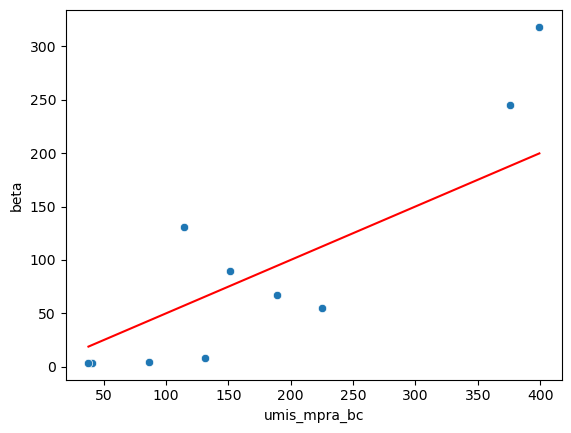

In [61]:
sns.scatterplot(mystery_df,x='umis_mpra_bc',y='beta')

x_vals = np.linspace(mystery_df['umis_mpra_bc'].min(), mystery_df['umis_mpra_bc'].max(), 200)
y_vals = x_vals**1/2

plt.plot(x_vals, y_vals, label='line', color='red')



Weird. Some of them look out of order? Let's examine another outlier.

# Positive control
Let's do one where we don't have a problem as a "positive control":

In [18]:
#pick one half-way through
description.sort_values(by="nb").iloc[int(np.floor(len(description)/2))]

C(cell_type)[Cardiomyocytes]                            0
C(cell_type)[EpiblastPrimitiveStreak]                   0
C(cell_type)[ExEndodermParietal]                        0
C(cell_type)[ExEndodermVisceral]                        0
C(cell_type)[Haematoendothelial]                        0
C(cell_type)[Mesoderm]                                  0
C(cell_type)[NeuroectodermBrain]                        0
C(cell_type)[NeuroectodermRostral]                      0
C(cell_type)[Pluripotent]                               1
C(cell_type)[SurfaceEctoderm]                           0
C(rep_id)[2B1]                                          0
C(rep_id)[2B2]                                          0
C(rep_id)[A1]                                           0
C(rep_id)[A2]                                           1
C(rep_id)[B1]                                           0
C(rep_id)[B2]                                           0
cre_id                                   Lamb1_chr12_2239
cells         

So the model says nb parameter (mean) is 0.084493 abnd zero-inflation is 0.60493, so it would predict an expected value of around 0.084493*(1-0.60493)=0.03338064951

In [19]:
control_set_of_interest=filtered[filtered["cre_id"]=="Lamb1_chr12_2239"][filtered["rep_id"]=="A2"][filtered["cell_type"]=="Pluripotent"]
control_set_of_interest['umis_mpra_bc'].agg('mean')

0.04950495049504951

That's pretty close. So the estimation procedure is working as expected here... Let's see if we can recap all the way from the original model.

In [21]:
primordial.by_cre.result().model["Lamb1_chr12_2239"]

{'llf_total': -609.7230998651876,
 'llfs': array([-609.72309987]),
 'aic_total': 1253.4461997303752,
 'aics': array([1253.44619973]),
 'df_model_total': 17,
 'df': 17,
 'weights': {'x_mu': array([[-1.5104022 ],
         [-2.9677577 ],
         [-0.80363244],
         [-1.5361302 ],
         [-2.8240786 ],
         [-4.7909293 ],
         [-4.3375564 ],
         [-3.7099843 ],
         [-2.4710915 ],
         [-3.143488  ]], dtype=float32),
  'x_pi': array([[-0.44259122],
         [-0.43982926],
         [ 0.5760552 ],
         [ 0.42604998],
         [-0.6193148 ],
         [-0.6938093 ]], dtype=float32),
  'theta': array([[-1.7793083]], dtype=float32)},
 'cpu_time': 0.6144118309020996,
 'num_sample': 3643,
 'epochs': 207}

In [20]:
primordial.by_cre.result().uniq_predictor["Lamb1_chr12_2239"][0]

,C(cell_type)[Cardiomyocytes],C(cell_type)[EpiblastPrimitiveStreak],C(cell_type)[ExEndodermParietal],C(cell_type)[ExEndodermVisceral],C(cell_type)[Haematoendothelial],C(cell_type)[Mesoderm],C(cell_type)[NeuroectodermBrain],C(cell_type)[NeuroectodermRostral],C(cell_type)[Pluripotent],C(cell_type)[SurfaceEctoderm]
38,0,1,0,0,0,0,0,0,0,0
377,0,0,0,0,1,0,0,0,0,0
480,0,0,0,0,0,0,0,0,1,0
547,0,0,0,0,0,0,0,1,0,0
798,0,0,0,1,0,0,0,0,0,0
1043,0,0,0,0,0,1,0,0,0,0
1525,0,0,0,0,0,0,0,0,0,1
2251,0,0,0,0,0,0,1,0,0,0
9829,1,0,0,0,0,0,0,0,0,0
10503,0,0,1,0,0,0,0,0,0,0


Pluripotent is second to last is $-2.4710915$. 
We assume a log-link. $e^{-2.4710915}=0.08449258499$ , which is exactly what we saw above

# finding borked values

In [15]:
r,p=scm.simulate_from_description(batch.description_primordial_by_cre)

scMPRAforge: WARNING: [simulate_from_description] explode took 0.21 seconds


In [11]:
len(r)

778015

In [ ]:
interval=100000
for i in [1,2,3,4]:
    print((interval*(i-1),interval*i))
    toy_r=r[interval*(i-1):interval*i]
    toy_p=p[interval*(i-1):interval*i]
    np.random.negative_binomial(n=toy_r, p=toy_p)

(0, 100000)
(100000, 200000)
(200000, 300000)


2025-06-22 14:35:42,258 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 14:35:42,259 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 14:35:42,259 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 14:35:42,259 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 14:35:42,259 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 14:35:42,260 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/

We have narrowed it down to the range (200000, 300000)

In [ ]:
start=200000
interval=50000
for i in range(1,11):
    print((start+interval*(i-1),start+interval*i))
    toy_r=r[start+interval*(i-1):start+interval*i]
    toy_p=p[start+interval*(i-1):start+interval*i]
    np.random.negative_binomial(n=toy_r, p=toy_p)

(200000, 250000)
(250000, 300000)


2025-06-22 14:38:35,408 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 14:38:35,408 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
2025-06-22 14:38:35,409 - distributed.nanny - ERROR - Worker process died unexpectedly
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/process.py", line 190, in _run
    target(*args, **kwargs)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/nanny.py", line 988, in _run
    asyncio.run(run())
  File "/opt/anaconda3/

Something in the range (250000, 300000)

In [ ]:
start=250000
interval=10000
for i in range(1,11):
    print((start+interval*(i-1),start+interval*i))
    toy_r=r[start+interval*(i-1):start+interval*i]
    toy_p=p[start+interval*(i-1):start+interval*i]
    np.random.negative_binomial(n=toy_r, p=toy_p)

(250000, 260000)


2025-06-22 14:43:16,417 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 14:43:16,417 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 14:43:16,417 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 14:43:16,417 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 14:43:16,418 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 14:43:16,418 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 14:43:16,418 - distributed.nanny - ERROR - Worker process died unexpectedly
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call

Something in the range (250000, 260000). Quick check, is it JUST something in that range?

In [ ]:
start=250000
interval=10000
for i in range(2,11):
    print((start+interval*(i-1),start+interval*i))
    toy_r=r[start+interval*(i-1):start+interval*i]
    toy_p=p[start+interval*(i-1):start+interval*i]
    np.random.negative_binomial(n=toy_r, p=toy_p)

(260000, 270000)


2025-06-22 14:52:02,732 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 14:52:02,732 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 14:52:02,733 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 14:52:02,733 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py"

No, it looks like the next section is borked as well. Let's inspect some values.

In [12]:
r[260000:270000]

array([0.00761527, 0.00761527, 0.00761527, ..., 0.07129764, 0.07129764,
       0.07129764], dtype=float32)

In [13]:
p[260000:270000]

array([7.37381939e-05, 7.37381939e-05, 7.37381939e-05, ...,
       1.56599487e-01, 1.56599487e-01, 1.56599487e-01])

In [15]:
np.random.negative_binomial(n=0.00761527, p=7.37381939e-05)
np.random.negative_binomial(n=0.07129764, p=1.56599487e-01)

0

Are any negative or zero?

In [20]:
any(r<0) or any(p<0) or any(r==0) or any(p==0)

False

Hrm, let's continue breaking it down.

In [ ]:
#(250000, 260000)
start=250000
interval=1000
for i in range(1,11):
    print((start+interval*(i-1),start+interval*i))
    toy_r=r[start+interval*(i-1):start+interval*i]
    toy_p=p[start+interval*(i-1):start+interval*i]
    np.random.negative_binomial(n=toy_r, p=toy_p)

(250000, 251000)


2025-06-22 15:27:51,582 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:27:51,582 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:27:51,582 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 15:27:51,582 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 15:27:51,583 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 15:27:51,583 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:27:51,583 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call

In [ ]:
#(250000, 251000)
start=250000
interval=100
for i in range(1,11):
    beg=start+interval*(i-1)
    end=start+interval*i
    print(beg,end)
    toy_r=r[beg:end]
    toy_p=p[beg:end]
    np.random.negative_binomial(n=toy_r, p=toy_p)

250000 250100
250100 250200
250200 250300
250300 250400
250400 250500
250500 250600
250600 250700


Now we're getting somewhere. (250600 250700)

In [ ]:
start=250600
interval=10
for i in range(1,11):
    beg=start+interval*(i-1)
    end=start+interval*i
    print(beg,end)
    toy_r=r[beg:end]
    toy_p=p[beg:end]
    np.random.negative_binomial(n=toy_r, p=toy_p)

250600 250610


2025-06-22 15:36:29,212 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:36:29,212 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:36:29,212 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 15:36:29,212 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 15:36:29,212 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 15:36:29,213 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/env_tensorzinb/lib/pyth

250600 250610

In [11]:
r[250600:250610]

array([0.00761527, 0.00761527, 0.00761527, 0.00761527, 0.00761527,
       0.00761527, 0.00761527, 0.00761527, 0.00761527, 0.00761527],
      dtype=float32)

In [12]:
p[250600:250610]

array([4.58092312e-109, 4.58092312e-109, 4.58092312e-109, 4.58092312e-109,
       4.58092312e-109, 4.58092312e-109, 4.58092312e-109, 4.58092312e-109,
       4.58092312e-109, 4.58092312e-109])

I bet there's something about the magnitude of p that's throwing the routine off.

In [13]:
min(p)

5.247322732074934e-141

In [ ]:
np.random.negative_binomial(n=[0.00761527], p=[4.58092312e-109])

2025-06-22 15:46:56,561 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:46:56,561 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:46:56,561 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 15:46:56,561 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-06-22 15:46:56,561 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-22 15:46:56,562 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-06-22 15:46:56,562 - distributed.nanny - ERROR - Worker process died unexpectedly
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs

In [8]:
batch.simulate_many(client,1)

[timing] extract arrays: 0.0001 seconds
[timing] sample ZINB: 0.0002 seconds
[timing] assign values: 0.0003 seconds
[timing] extract arrays: 0.0001 seconds
[timing] extract arrays: 0.0000 seconds
[timing] extract arrays: 0.0000 seconds
[timing] extract arrays: 0.0001 seconds
[timing] sample ZINB: 0.0084 seconds
[timing] assign values: 0.0002 seconds
[timing] sample ZINB: 0.0125 seconds
[timing] assign values: 0.0007 seconds
[timing] extract arrays: 0.0000 seconds
[timing] extract arrays: 0.0001 seconds
[timing] extract arrays: 0.0001 seconds
[timing] sample ZINB: 0.0041 seconds
[timing] assign values: 0.0002 seconds
[timing] extract arrays: 0.0001 seconds
[timing] sample ZINB: 0.0036 seconds
[timing] assign values: 0.0002 seconds


ERROR:tornado.application:Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOLoop object at 0x3290853f0>>, <Task finished name='Task-28266' coro=<ProfileTimePlot.trigger_update.<locals>.cb() done, defined at /opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/utils.py:739> exception=AttributeError("'NoneType' object has no attribute 'add_next_tick_callback'")>)
Traceback (most recent call last):
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/tornado/ioloop.py", line 782, in _discard_future_result
    future.result()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/utils.py", line 741, in wrapper
    return await func(*args, **kwargs)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-pa

[timing] extract arrays: 0.0001 seconds
[timing] extract arrays: 0.0000 seconds
[timing] sample ZINB: 0.0083 seconds
[timing] assign values: 0.0002 seconds
[timing] sample ZINB: 0.0096 seconds
[timing] assign values: 0.0002 seconds
[timing] extract arrays: 0.0000 seconds
[timing] extract arrays: 0.0000 seconds
[timing] extract arrays: 0.0001 seconds


KeyboardInterrupt: 

2025-06-20 16:27:54,691 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/process.py", line 190, in _run
    target(*args, **kwargs)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/nanny.py", line 988, in _run
    asyncio.run(run())
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/asyncio/runners.py", line 44, in run
    return loop.run_until_complete(main)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/asyncio/ba

In [ ]:
batch.fit_to_simulations(client)

In [ ]:
batch._flatten_all_parameters()

In [ ]:
batch.plot_nb_spread()

In [17]:
cluster.close()